# 01 · Exploración del panel y de la censura

**Blindside** — pronóstico de demanda de perecederos con recuperación de demanda censurada.

Este notebook responde cuatro preguntas, en este orden:

1. ¿Qué hay en el panel? Dimensiones, jerarquías, cobertura temporal.
2. ¿Cómo se distribuye la demanda? Y por qué eso descarta MAPE como métrica.
3. ¿Cuánta censura hay, y dónde?
4. ¿El supuesto de la ventana comercial es el correcto? Esto se **verifica**, no se asume.

## Regla de este directorio

Los notebooks **importan de `src/blindside` y no contienen lógica**. Si algo se calcula acá
y no en el paquete, no tiene test y no llega a producción. Cuando un cálculo hace falta,
va al paquete y el notebook lo llama. Es la razón por la que estas celdas son cortas.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from blindside import config as cfg
from blindside.data import loaders
from blindside.data import schema as S

pd.set_option("display.width", 110)
pd.set_option("display.max_columns", 40)
plt.rcParams.update({"figure.figsize": (9, 3.2), "axes.grid": True, "grid.alpha": 0.25})

print(f"semilla del proyecto: {cfg.SEED}")
print(f"horizonte: {cfg.FORECAST.horizon} d · orígenes: {cfg.FORECAST.n_origins}")
print(f"economía: Cu={cfg.ECONOMICS.cu} Co={cfg.ECONOMICS.co} → q*={cfg.ECONOMICS.critical_fraction:.3f}")

semilla del proyecto: 42
horizonte: 7 d · orígenes: 8
economía: Cu=1.0 Co=0.6 → q*=0.625


## 1 · Qué hay en el panel

`load_demand()` trae la capa con la demanda latente ya recuperada (`data/processed/`). Si esa
capa no existe, cae a `data/sample/`, que sí está commiteada — el repo se puede correr sin
descargar nada, y el notebook lo dice en vez de fallar.

In [2]:
ruta = loaders.resolve_path("demand")
panel = loaders.load_demand(path=ruta)
es_muestra = ruta.parent == cfg.DATA_SAMPLE

print(f"capa servida: {ruta.parent.name}{'  (MUESTRA, no el panel completo)' if es_muestra else ''}")
print(f"filas      : {len(panel):,}")
print(f"series     : {panel[S.SERIES_ID].nunique():,}")
print(f"tiendas    : {panel[S.STORE_ID].nunique():,}")
print(f"productos  : {panel[S.PRODUCT_ID].nunique():,}")
print(f"días       : {panel[S.DATE].nunique()}  ({panel[S.DATE].min().date()} → {panel[S.DATE].max().date()})")
print(f"ciudades   : {panel[S.CITY_ID].nunique()}")

capa servida: processed
filas      : 297,402
series     : 3,066
tiendas    : 38
productos  : 309
días       : 97  (2024-03-28 → 2024-07-02)
ciudades   : 2


### El panel es denso, no ralo

Vale comprobarlo antes de construir lags: si faltaran filas, un `shift(1)` por serie tomaría
el día anterior *disponible* y no el día anterior *calendario*, que son cosas distintas.

In [3]:
esperadas = panel[S.SERIES_ID].nunique() * panel[S.DATE].nunique()
print(f"filas esperadas si fuera un panel perfecto: {esperadas:,}")
print(f"filas reales                              : {len(panel):,}")
print(f"densidad                                  : {len(panel) / esperadas:.4%}")

por_serie = panel.groupby(S.SERIES_ID, observed=True)[S.DATE].nunique()
print(f"\ndías por serie: mín {por_serie.min()}, mediana {por_serie.median():.0f}, máx {por_serie.max()}")

filas esperadas si fuera un panel perfecto: 297,402
filas reales                              : 297,402
densidad                                  : 100.0000%

días por serie: mín 97, mediana 97, máx 97


## 2 · Cómo se distribuye la demanda

Acá está el argumento de por qué la métrica principal es **MASE** y no MAPE. MAPE divide por
el valor real, así que explota cuando la demanda se acerca a cero — y en un catálogo de
perecederos la mayoría de los productos son de baja rotación con días en cero.

In [4]:
obs = panel[S.SALE_AMOUNT]
lat = panel[S.DEMAND_LATENT]

resumen = pd.DataFrame(
    {
        "venta observada": obs.describe(percentiles=[0.5, 0.9, 0.99]),
        "demanda latente": lat.describe(percentiles=[0.5, 0.9, 0.99]),
    }
)
display(resumen.round(4))

print(f"días con venta exactamente cero: {(obs <= 0).mean():.2%}")
print(f"p99 / mediana (latente)        : {lat.quantile(0.99) / lat.median():.1f}×")
print("\nEse cociente es el que hace que un intervalo de ancho constante no sirva:")
print("un cuantil de residuos agrupado sobre este panel queda dominado por la cola.")
print("Es la razón de ser de CQR, en el notebook 05.")

,venta observada,demanda latente
count,297402.0000,297402.0000
mean,1.0087,1.2218
std,1.1066,1.3902
min,0.0000,0.0000
50%,0.7000,0.8037
90%,2.1000,2.5889
99%,5.6000,6.7498
max,23.8000,53.0010


días con venta exactamente cero: 3.06%
p99 / mediana (latente)        : 8.4×

Ese cociente es el que hace que un intervalo de ancho constante no sirva:
un cuantil de residuos agrupado sobre este panel queda dominado por la cola.
Es la razón de ser de CQR, en el notebook 05.


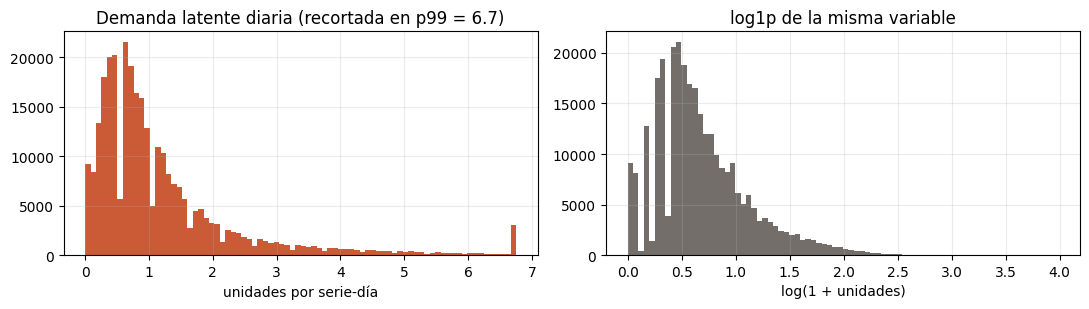

La cola derecha es lo que se ve a la izquierda. En log deja de ser una pared,
pero el modelo NO se entrena en log: la pérdida cuantílica en q* tiene que
optimizar el cuantil de la escala en la que se decide la orden.


In [5]:
fig, ejes = plt.subplots(1, 2, figsize=(11, 3.2))
corte = float(lat.quantile(0.99))
ejes[0].hist(lat.clip(upper=corte), bins=80, color="#C23D14", alpha=0.85)
ejes[0].set_title(f"Demanda latente diaria (recortada en p99 = {corte:.1f})")
ejes[0].set_xlabel("unidades por serie-día")

ejes[1].hist(np.log1p(lat), bins=80, color="#5A5550", alpha=0.85)
ejes[1].set_title("log1p de la misma variable")
ejes[1].set_xlabel("log(1 + unidades)")
fig.tight_layout()
plt.show()

print("La cola derecha es lo que se ve a la izquierda. En log deja de ser una pared,")
print("pero el modelo NO se entrena en log: la pérdida cuantílica en q* tiene que")
print("optimizar el cuantil de la escala en la que se decide la orden.")

### Estacionalidad semanal

Es la señal que justifica un `season_length` de 7 y que el baseline a batir sea el **naive
estacional** y no el naive simple.

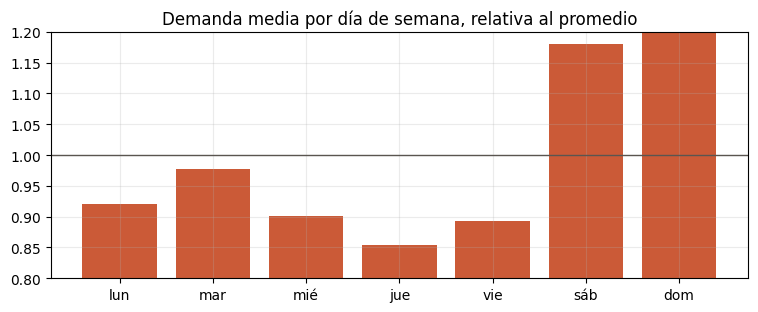

amplitud pico a valle: 41.9% del nivel medio


In [6]:
dias = ["lun", "mar", "mié", "jue", "vie", "sáb", "dom"]
por_dow = panel.assign(dow=panel[S.DATE].dt.dayofweek).groupby("dow")[S.DEMAND_LATENT].mean()
relativo = por_dow / por_dow.mean()

fig, eje = plt.subplots()
eje.bar(dias, relativo.to_numpy(), color="#C23D14", alpha=0.85)
eje.axhline(1.0, color="#5A5550", lw=1)
eje.set_title("Demanda media por día de semana, relativa al promedio")
eje.set_ylim(0.8, 1.2)
plt.show()

print(f"amplitud pico a valle: {relativo.max() - relativo.min():.1%} del nivel medio")

### La cola de rotación

`rotation_bands` corta el catálogo por cuantiles de demanda media. Las bandas se usan después
para desagregar métricas: un MASE global bueno puede esconder que el modelo falla justo en la
cola, que es la mayoría de los SKU.

In [7]:
from blindside.validation.splits import rotation_bands

bandas = rotation_bands(panel, target=S.DEMAND_LATENT)
conteo = bandas.value_counts()
media_por_banda = panel.assign(banda=panel[S.SERIES_ID].map(bandas)).groupby("banda", observed=True)[
    S.DEMAND_LATENT
].mean()

display(
    pd.DataFrame({"series": conteo, "demanda media": media_por_banda.round(3)}).sort_values(
        "demanda media"
    )
)
print("Los tamaños de grupo no son informativos por construcción: las bandas son")
print("cortes por cuantil, así que 'baja' es la mitad del catálogo por definición.")
print("Lo informativo es la razón de niveles entre bandas.")

,series,demanda media
baja,1533,0.638
media,1073,1.193
alta,460,3.234


Los tamaños de grupo no son informativos por construcción: las bandas son
cortes por cuantil, así que 'baja' es la mitad del catálogo por definición.
Lo informativo es la razón de niveles entre bandas.


## 3 · La censura: cuánta hay y dónde

Un día está censurado cuando hubo horas de quiebre dentro de la ventana comercial. La venta
registrada ese día es menor que la demanda que había, y entrenar sobre ella produce el
**efecto spiral-down**: se pide de menos, hay más quiebres, se observa menos demanda.

In [8]:
censurado = panel[S.IS_CENSORED].astype(bool)
print(f"días con quiebre                : {censurado.mean():.2%}")
print(f"horas de quiebre cuando hay     : {panel.loc[censurado, S.OOS_HOURS_OPEN].mean():.2f} h")
print(f"días con venta cero             : {(panel[S.SALE_AMOUNT] <= 0).mean():.2%}")
print(f"días con quiebre Y venta cero   : {(censurado & (panel[S.SALE_AMOUNT] <= 0)).mean():.2%}")

uplift = pd.DataFrame(
    {
        "observada": [
            panel[S.SALE_AMOUNT].mean(),
            panel.loc[~censurado, S.SALE_AMOUNT].mean(),
            panel.loc[censurado, S.SALE_AMOUNT].mean(),
        ],
        "latente": [
            panel[S.DEMAND_LATENT].mean(),
            panel.loc[~censurado, S.DEMAND_LATENT].mean(),
            panel.loc[censurado, S.DEMAND_LATENT].mean(),
        ],
    },
    index=["todos los días", "días SIN quiebre", "días CON quiebre"],
)
uplift["uplift"] = uplift["latente"] / uplift["observada"] - 1
display(uplift.round(4))

días con quiebre                : 43.89%
horas de quiebre cuando hay     : 7.00 h
días con venta cero             : 3.06%
días con quiebre Y venta cero   : 2.13%


,observada,latente,uplift
todos los días,1.0087,1.2218,0.2112
días SIN quiebre,0.9793,0.9793,0.0000
días CON quiebre,1.0463,1.5318,0.4640


**El 0,00 % de los días sin quiebre es por diseño, no casualidad.** Esos días son la verdad de
terreno con la que se mide el sesgo: si la corrección los tocara, no quedaría nada contra lo
que validarla. La celda de abajo lo verifica como una aserción y no como una observación.

In [9]:
limpios = panel.loc[~censurado]
diferencia = (limpios[S.DEMAND_LATENT] - limpios[S.SALE_AMOUNT]).abs().max()
assert diferencia < 1e-9, f"la corrección tocó días limpios: máx |Δ| = {diferencia}"
print(f"máxima diferencia en días sin quiebre: {diferencia:.2e}  → la corrección no los toca")

máxima diferencia en días sin quiebre: 0.00e+00  → la corrección no los toca


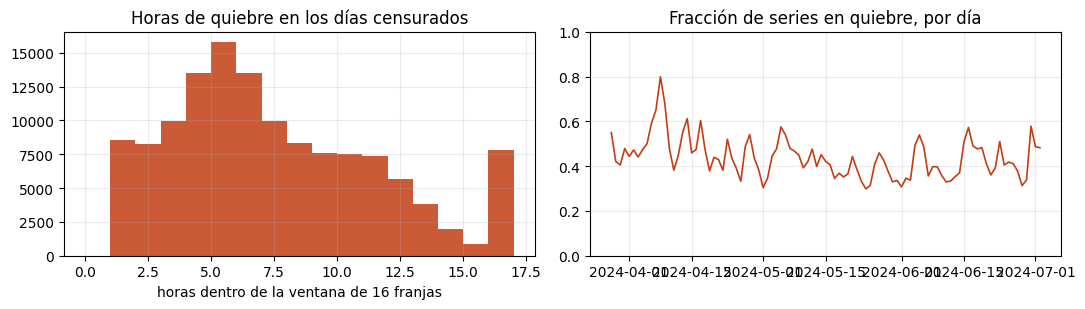

In [10]:
fig, ejes = plt.subplots(1, 2, figsize=(11, 3.2))

horas = panel.loc[censurado, S.OOS_HOURS_OPEN]
ejes[0].hist(horas, bins=range(0, 18), color="#C23D14", alpha=0.85)
ejes[0].set_title("Horas de quiebre en los días censurados")
ejes[0].set_xlabel(f"horas dentro de la ventana de {len(cfg.CENSORING.open_hours)} franjas")

por_dia = panel.groupby(S.DATE)[S.IS_CENSORED].mean()
ejes[1].plot(por_dia.index, por_dia.to_numpy(), color="#C23D14", lw=1.2)
ejes[1].set_title("Fracción de series en quiebre, por día")
ejes[1].set_ylim(0, 1)
fig.tight_layout()
plt.show()

### Rachas de quiebre

Importan para la capa de decisión: una serie con una racha de decenas de días no tiene señal
reciente recuperable, y el pronóstico para ella es una extrapolación de historia vieja. La
interfaz necesita poder decirlo en vez de mostrar un número con la misma confianza que el resto.

In [11]:
orden = panel.sort_values([S.SERIES_ID, S.DATE], kind="mergesort")
marca = orden[S.IS_CENSORED].astype(bool)
# Identificador de racha: cambia cada vez que la marca cambia dentro de la serie.
grupo = (marca != marca.groupby(orden[S.SERIES_ID], observed=True).shift()).cumsum()
rachas = marca.groupby([orden[S.SERIES_ID], grupo], observed=True).agg(["sum", "size"])
largos = rachas.loc[rachas["sum"] > 0, "size"]

print(f"rachas de quiebre          : {len(largos):,}")
print(f"largo mediano              : {largos.median():.0f} días")
print(f"largo p95                  : {largos.quantile(0.95):.0f} días")
print(f"racha más larga            : {largos.max()} días")
print(f"series con racha ≥ 30 días : {(rachas.loc[rachas['sum'] > 0].groupby(level=0)['size'].max() >= 30).sum():,}")

rachas de quiebre          : 53,072
largo mediano              : 2 días
largo p95                  : 6 días
racha más larga            : 95 días
series con racha ≥ 30 días : 50


## 4 · Verificación del supuesto de ventana comercial

La ficha del dataset declara «≈ 20 % de horas comerciales en quiebre». Ese número se puede
**reconstruir** desde el panel, y si no coincide es que la ventana comercial asumida está mal.

$$\text{horas en quiebre} = \frac{\text{días con quiebre} \times \text{horas promedio}}{\text{franjas comerciales}}$$

El proyecto asume **16 franjas** (6:00 a 21:59, ver `docs/decisiones.md` D9). Con 17 el número
no cierra.

In [12]:
franjas = len(cfg.CENSORING.open_hours)
share_dias = float(censurado.mean())
horas_medias = float(panel.loc[censurado, S.OOS_HOURS_OPEN].mean())

for n in (franjas, franjas + 1):
    derivado = share_dias * horas_medias / n
    marca_ok = "  ← el supuesto del proyecto" if n == franjas else ""
    print(f"con {n} franjas: {share_dias:.3f} × {horas_medias:.2f} / {n} = {derivado:.3%}{marca_ok}")

print(f"\nla ficha del dataset declara ≈ 20 %")
print(f"ventana asumida: {min(cfg.CENSORING.open_hours)}:00 a {max(cfg.CENSORING.open_hours)}:59")

con 16 franjas: 0.439 × 7.00 / 16 = 19.195%  ← el supuesto del proyecto
con 17 franjas: 0.439 × 7.00 / 17 = 18.066%

la ficha del dataset declara ≈ 20 %
ventana asumida: 6:00 a 21:59


Con 16 franjas el cálculo reproduce el ≈20 % publicado. **Y esto no queda solo acá:** el código
de recuperación falla si las horas derivadas de la máscara horaria no coinciden con la columna
`stock_hour6_22_cnt`, así que el supuesto se re-verifica en cada corrida del pipeline y no una
sola vez en un notebook.

## 5 · El perfil intradiario, que es el mecanismo de la corrección

La recuperación no infla la venta por una constante. Usa el **perfil horario** de la serie para
estimar qué fracción de la demanda diaria cayó en las horas que estuvieron sin stock, y sólo
repone esa fracción. Requiere la capa horaria, que no siempre está en disco.

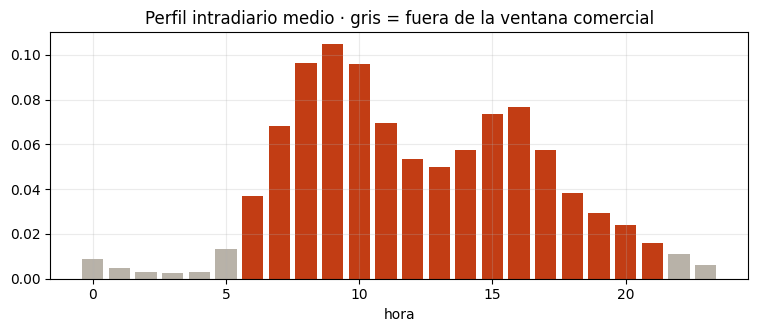

masa de demanda fuera de la ventana comercial: 5.2803%
Si fuera grande, la ventana estaría mal elegida y la corrección repartiría
demanda hacia horas en las que el local no vende.


In [13]:
try:
    horario = loaders.load_hourly_panel()
except loaders.DataNotAvailableError as exc:
    horario = None
    print(f"sin capa horaria: {exc}")
    print("correr 'make data' para reproducir esta sección")

if horario is not None:
    secuencias = np.vstack(horario[S.HOURS_SALE].apply(np.asarray).to_numpy())
    perfil = secuencias.mean(axis=0)
    perfil = perfil / perfil.sum()

    fig, eje = plt.subplots()
    colores = ["#C23D14" if h in cfg.CENSORING.open_hours else "#B8B2A8" for h in range(24)]
    eje.bar(range(24), perfil, color=colores)
    eje.set_title("Perfil intradiario medio · gris = fuera de la ventana comercial")
    eje.set_xlabel("hora")
    plt.show()

    fuera = sum(perfil[h] for h in range(24) if h not in cfg.CENSORING.open_hours)
    print(f"masa de demanda fuera de la ventana comercial: {fuera:.4%}")
    print("Si fuera grande, la ventana estaría mal elegida y la corrección repartiría")
    print("demanda hacia horas en las que el local no vende.")

## Lo que sale de acá

| Hallazgo | Consecuencia en el proyecto |
|---|---|
| Demanda con cola derecha larga y días en cero | MASE como métrica principal, MAPE descartado (D5) |
| p99 / mediana ≈ 12× | Un intervalo de ancho constante no puede estar calibrado → CQR (notebook 05) |
| Estacionalidad semanal clara | `season_length = 7`; el baseline a batir es el naive **estacional** |
| ~44 % de días con quiebre, ~7 h cada uno | La corrección de censura va **antes** de las features (D4) |
| Uplift exactamente 0 % en días limpios | Es la verdad de terreno de la validación, y se verifica con un assert |
| 16 franjas reproduce el ≈20 % de la ficha | El supuesto de ventana comercial queda verificado, no asumido (D9) |
| Rachas de quiebre de decenas de días | La interfaz necesita un estado propio para esas series |

**Sigue:** `02_features_validacion.ipynb` — construir las features sin mirar el futuro, y los
asserts que lo demuestran.